<a href="https://colab.research.google.com/github/faleroid/cv-retinal/blob/main/Template_Submission_Akhir_Naufal_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyek Klasifikasi Gambar: Retinal OCT Condition C8
- **Nama:** Naufal Satrio Putra
- **Email:** naufalsatrioputra@gmail.com
- **ID Dicoding:** nflssz

## Import Semua Packages/Library yang Digunakan

In [1]:
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq

import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, GlobalAveragePooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

ModuleNotFoundError: No module named 'cv2'

## Data Preparation

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [1]:
# from google.colab import files
# files.upload()

### Data Loading

In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')
!unzip -q "/content/drive/MyDrive/dataset.zip" -d "/content/"

### EDA

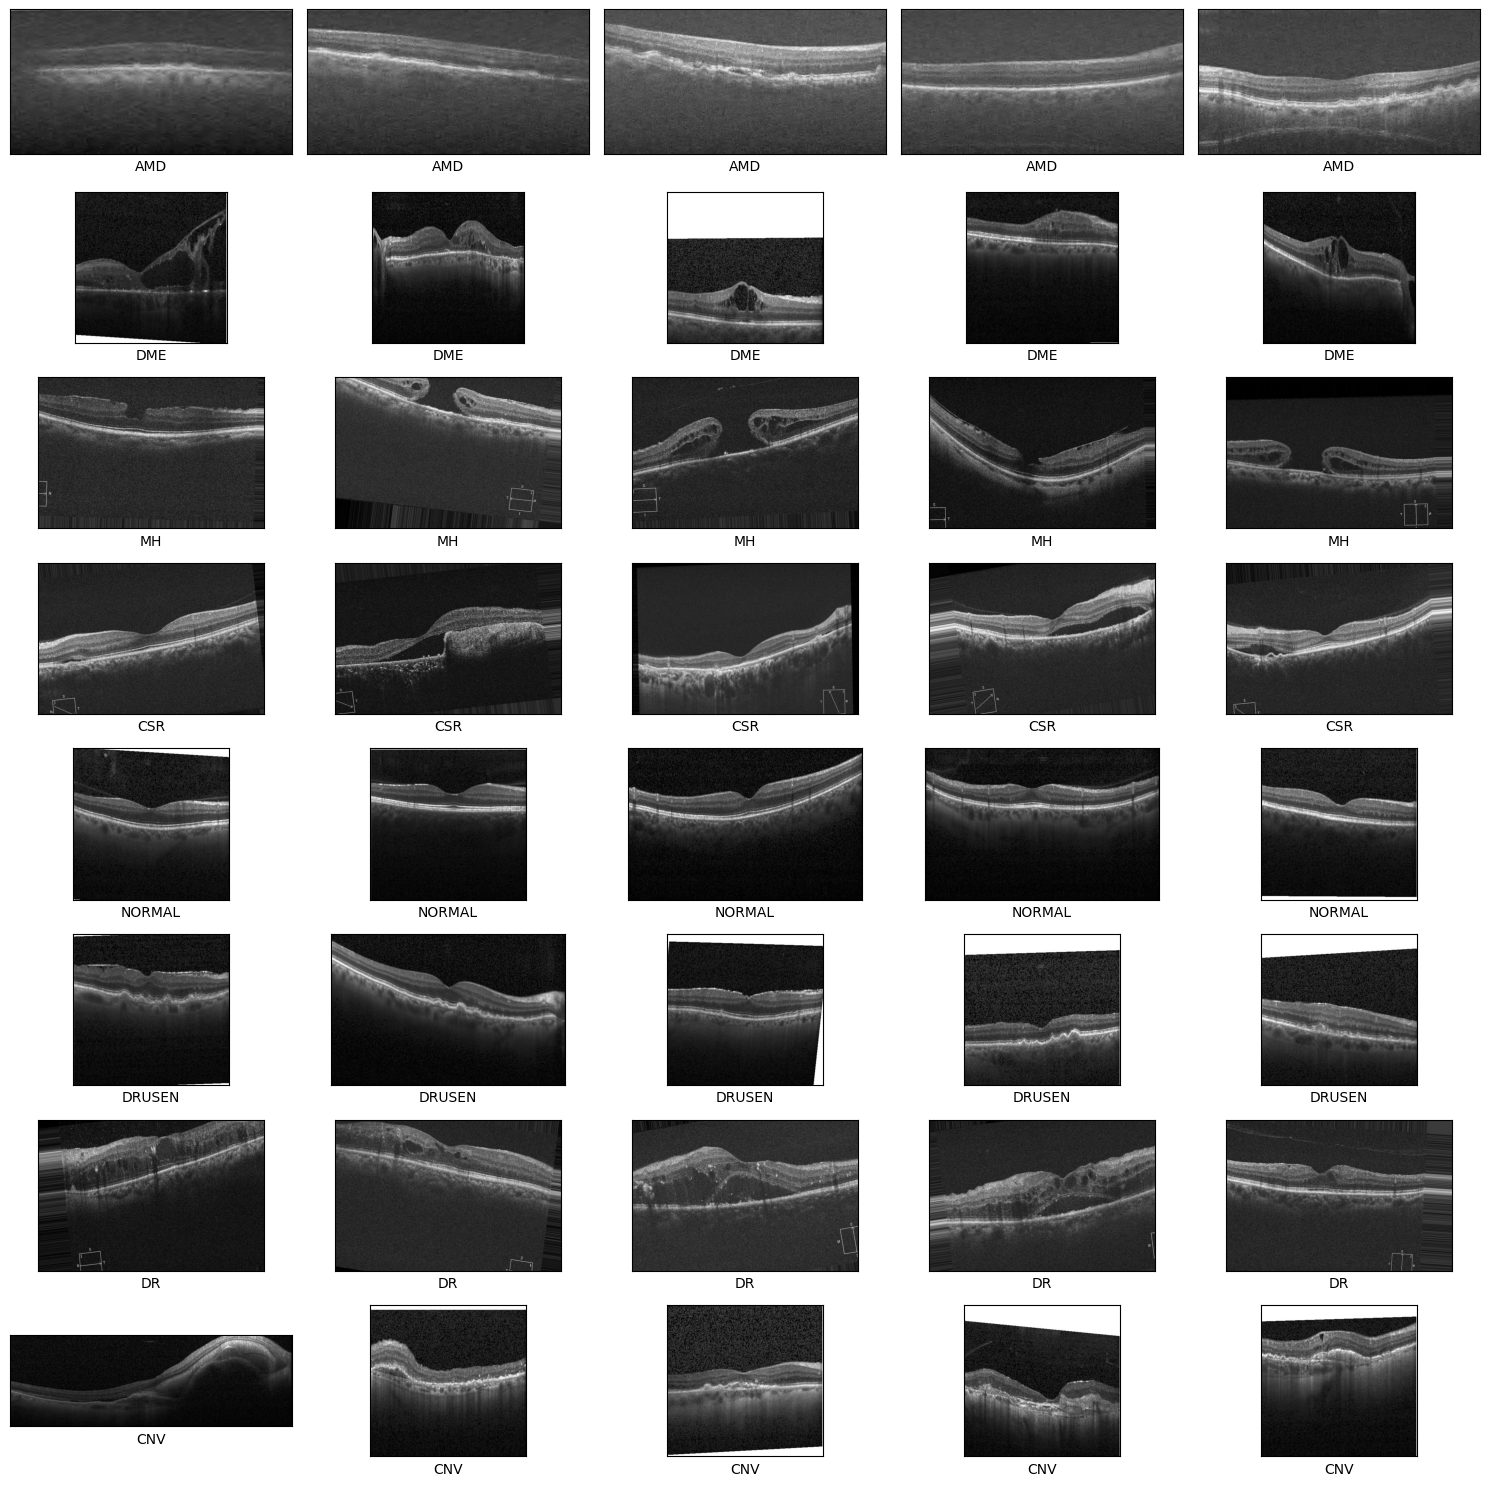

In [ ]:
image = {}

# Tentukan path sumber train
path = "RetinalOCT_Dataset/"
path_sub = os.path.join(path, "RetinalOCT_Dataset/train")
for i in os.listdir(path_sub):
    image[i] = os.listdir(os.path.join(path_sub, i))

# Menampilkan secara acak 5 gambar di bawah setiap kelas dari data latih
fig, axs = plt.subplots(len(image.keys()), 5, figsize=(15, 15))

for i, class_name in enumerate(os.listdir(path_sub)):
    images = np.random.choice(image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path_sub, class_name, image_name)
        img = Image.open(img_path).convert("L")  # Konversi menjadi skala keabuan
        axs[i, j].imshow(img, cmap='gray')
        axs[i, j].set(xlabel=class_name, xticks=[], yticks=[])


fig.tight_layout()

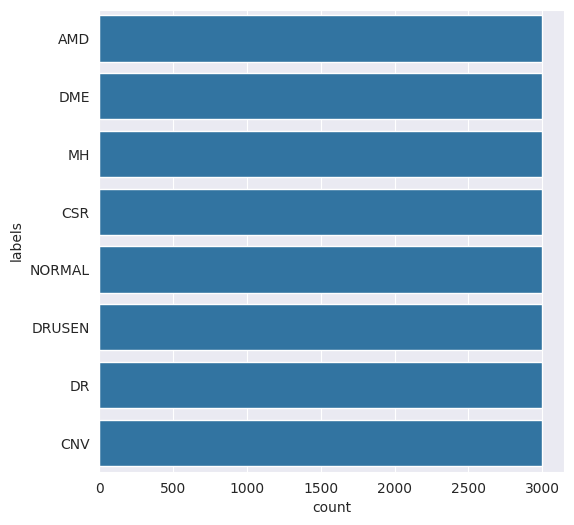

In [ ]:
path = "RetinalOCT_Dataset/RetinalOCT_Dataset"

file_name = []
labels = []
full_path = []

for root, subdirs, files in os.walk(path):
    for name in files:
        full_path.append(os.path.join(root, name))
        labels.append(root.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label)

In [ ]:
distribution_train.sample(5)

,path,file_name,labels
20455,RetinalOCT_Dataset/RetinalOCT_Dataset/train/CN...,cnv_train_1510.jpg,CNV
19032,RetinalOCT_Dataset/RetinalOCT_Dataset/train/CN...,cnv_train_2482.jpg,CNV
20394,RetinalOCT_Dataset/RetinalOCT_Dataset/train/CN...,cnv_train_1686.jpg,CNV
23804,RetinalOCT_Dataset/RetinalOCT_Dataset/val/CNV/...,cnv_val_1068.jpg,CNV
13104,RetinalOCT_Dataset/RetinalOCT_Dataset/train/NO...,normal_train_2573.jpg,NORMAL


In [5]:
from PIL import Image
import os

def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)
        print(f"{subdir}: {num_images}")
        total_images += num_images

        for img_file in image_files:
            img_path = os.path.join(subdir_path, img_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f"- {size}")
        print("---------------")

    print(f"\nTotal: {total_images}")

print_images_resolution("RetinalOCT_Dataset/RetinalOCT_Dataset/val/")

AMD: 350
- (1000, 512)
---------------
CNV: 350
- (1000, 512)
- (512, 496)
- (1024, 496)
- (1536, 496)
- (768, 496)
---------------
CSR: 350
- (1000, 512)
- (512, 496)
- (879, 586)
- (1024, 496)
- (750, 500)
- (1536, 496)
- (768, 496)
---------------
DME: 350
- (1000, 512)
- (512, 512)
- (512, 496)
- (879, 586)
- (1024, 496)
- (750, 500)
- (1536, 496)
- (768, 496)
---------------
DR: 350
- (1000, 512)
- (512, 512)
- (512, 496)
- (879, 586)
- (1024, 496)
- (750, 500)
- (1536, 496)
- (768, 496)
---------------
DRUSEN: 350
- (1000, 512)
- (512, 512)
- (512, 496)
- (879, 586)
- (1024, 496)
- (750, 500)
- (1536, 496)
- (768, 496)
---------------
MH: 350
- (1000, 512)
- (512, 512)
- (512, 496)
- (879, 586)
- (1024, 496)
- (750, 500)
- (1536, 496)
- (768, 496)
---------------
NORMAL: 350
- (1000, 512)
- (512, 512)
- (512, 496)
- (879, 586)
- (1024, 496)
- (750, 500)
- (384, 496)
- (1536, 496)
- (768, 496)
---------------

Total: 2800


### Data Preprocessing

In [ ]:
mypath= 'dataset/'

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(mypath):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(os.path.basename(path))
        file_name.append(name)

df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
df.groupby(['labels']).size()

In [ ]:
X= df['path']
y= df['labels']

X_train, X_others, y_train, y_others = train_test_split(
    X, y, test_size=0.2, random_state=300, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_others, y_others, test_size=0.5, random_state=300, stratify=y_others
)

In [ ]:
df_tr = pd.DataFrame({'path': X_train, 'labels': y_train, 'set': 'train'})
df_va = pd.DataFrame({'path': X_val, 'labels': y_val, 'set': 'val'})
df_te = pd.DataFrame({'path': X_test, 'labels': y_test, 'set': 'test'})

In [ ]:
df_all = pd.concat([df_tr, df_va, df_te], ignore_index=True)

print('===================================================== \n')
print(df_all.groupby(['set', 'labels']).size(), '\n')
print('===================================================== \n')

print(df_all.sample(5))

datasource_path = "dataset/"
dataset_path = "dataset-final/"

In [ ]:
for index, row in tq(df_all.iterrows()):
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(datasource_path,row['labels'],row['image'].split('.')[0])

    if os.path.exists(os.path.join(dataset_path,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path,row['set'],row['labels']))

    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path,row['set'],row['labels'],destination_file_name)

    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

## Modelling

In [ ]:
train_generator = train_datagen.flow_from_directory(
    'dataset/train',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    'dataset/val',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    directory='dataset/test',
    target_size=(224, 224),
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 18400 images belonging to 8 classes.
Found 2800 images belonging to 8 classes.
Found 2800 images belonging to 8 classes.


In [ ]:
from tensorflow.keras.applications import DenseNet121

base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = Sequential()
model.add(base_model)

In [ ]:
model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(8, activation='softmax'))

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
checkpoint = ModelCheckpoint(
    'model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1,
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1,
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,177,480 (27.38 MB)

 Trainable params: 139,976 (546.78 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [ ]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 50,
    callbacks=[checkpoint, early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.3852 - loss: 1.6173
Epoch 1: val_accuracy improved from -inf to 0.75964, saving model to model.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 314s 497ms/step - accuracy: 0.3854 - loss: 1.6167 - val_accuracy: 0.7596 - val_loss: 0.6864
Epoch 2/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 423ms/step - accuracy: 0.6786 - loss: 0.8340
Epoch 2: val_accuracy improved from 0.75964 to 0.80250, saving model to model.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 255s 443ms/step - accuracy: 0.6786 - loss: 0.8339 - val_accuracy: 0.8025 - val_loss: 0.5664
Epoch 3/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.7203 - loss: 0.7308
Epoch 3: val_accuracy did not improve from 0.80250
575/575 ━━━━━━━━━━━━━━━━━━━━ 255s 444ms/step - accuracy: 0.7203 - loss: 0.7308 - val_accuracy: 0.7943 - val_loss: 0.5755
Epoch 4/50
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.7468 - loss: 0.6631
Epoch 4: val_accuracy improved from 0.80250 to 0.83071, saving model 

In [ ]:
base_model = model.layers[0]

base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False


model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

checkpoint_finetune = ModelCheckpoint(
    'best_retinal_model_finetuned.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

early_stop_finetune = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)


history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20, # Tidak perlu terlalu banyak
    callbacks=[checkpoint_finetune, early_stop_finetune]
)

Epoch 1/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.5112 - loss: 1.9988
Epoch 1: val_accuracy improved from -inf to 0.84036, saving model to best_retinal_model_finetuned.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 438s 526ms/step - accuracy: 0.5114 - loss: 1.9975 - val_accuracy: 0.8404 - val_loss: 0.4553
Epoch 2/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.7998 - loss: 0.5731
Epoch 2: val_accuracy improved from 0.84036 to 0.89071, saving model to best_retinal_model_finetuned.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 279s 486ms/step - accuracy: 0.7999 - loss: 0.5730 - val_accuracy: 0.8907 - val_loss: 0.3001
Epoch 3/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.8514 - loss: 0.4168
Epoch 3: val_accuracy improved from 0.89071 to 0.90786, saving model to best_retinal_model_finetuned.keras
575/575 ━━━━━━━━━━━━━━━━━━━━ 279s 485ms/step - accuracy: 0.8514 - loss: 0.4168 - val_accuracy: 0.9079 - val_loss: 0.2674
Epoch 4/20
575/575 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step -

## Evaluasi dan Visualisasi

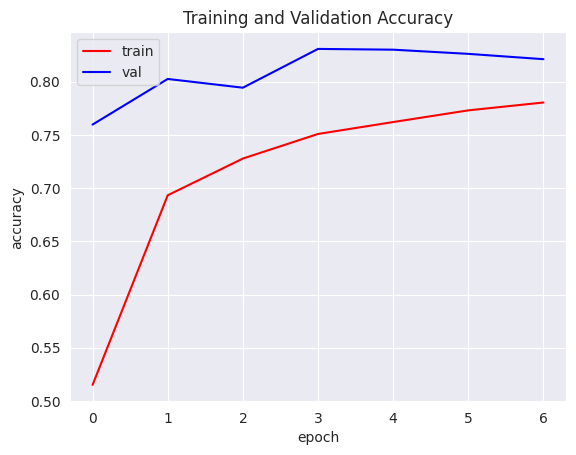

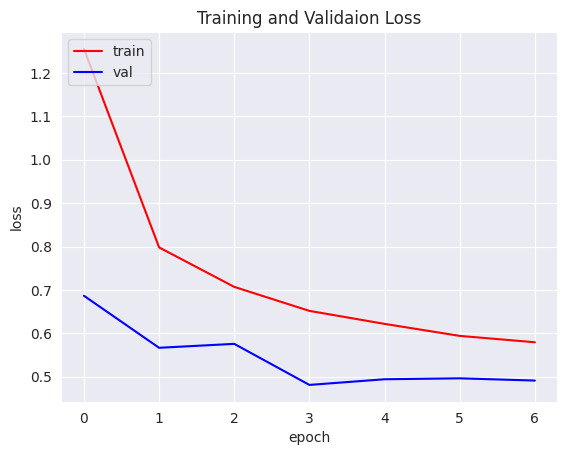

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r')
plt.plot(epochs, val_acc, 'b')
plt.title('Training and Validation Accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.title('Training and Validaion Loss')
plt.show()

88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - accuracy: 0.9633 - loss: 0.1135
Acc Test: 96.00% | Loss: 0.1282

88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step


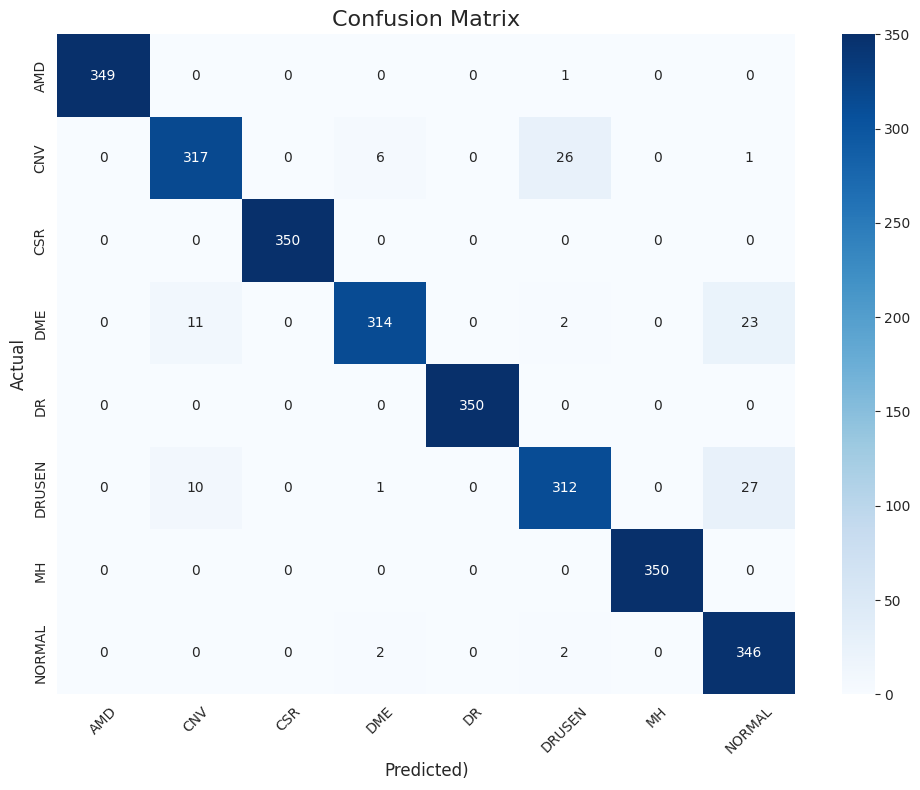

              precision    recall  f1-score   support

         AMD       1.00      1.00      1.00       350
         CNV       0.94      0.91      0.92       350
         CSR       1.00      1.00      1.00       350
         DME       0.97      0.90      0.93       350
          DR       1.00      1.00      1.00       350
      DRUSEN       0.91      0.89      0.90       350
          MH       1.00      1.00      1.00       350
      NORMAL       0.87      0.99      0.93       350

    accuracy                           0.96      2800
   macro avg       0.96      0.96      0.96      2800
weighted avg       0.96      0.96      0.96      2800



In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Acc Test: {test_accuracy * 100:.2f}% | Loss: {test_loss:.4f}\n")

predictions = model.predict(test_generator)

y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

## Konversi Model

In [ ]:
base_model = DenseNet121(weights=None, include_top=False, input_shape=(224, 224, 3))

model = Sequential()
model.add(base_model)

model.add(GlobalAveragePooling2D())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(8, activation='softmax'))

model.build((None, 224, 224, 3))

model.load_weights('best_retinal_model_finetuned.keras')

export_path = 'retinal_saved_model'
model.export(export_path)

INFO:tensorflow:Assets written to: retinal_saved_model\assets


INFO:tensorflow:Assets written to: retinal_saved_model\assets


Saved artifact at 'retinal_saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_4043')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  1556458482832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458485904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458486672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458486288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458486480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458487248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458487440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458486864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458487056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458483216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1556458480720: TensorSpec(

## Inference (Optional)

In [ ]:
S

Predict: NORMAL
Confidence: 94.40%

Probability
- AMD: 0.03%
- CNV: 0.00%
- CSR: 0.00%
- DME: 0.94%
- DR: 0.00%
- DRUSEN: 4.63%
- MH: 0.00%
- NORMAL: 94.40%
